In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
months = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6','Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']
features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA', 'Percent_Bleaching']

In [3]:
df = pd.read_csv("best_data.csv")

In [4]:
df = df[features + months]

# PCA

In [5]:
X = df.drop("Percent_Bleaching", axis=1)
Y = df["Percent_Bleaching"]

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'])

In [8]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

In [9]:
pca = PCA(n_components=1)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

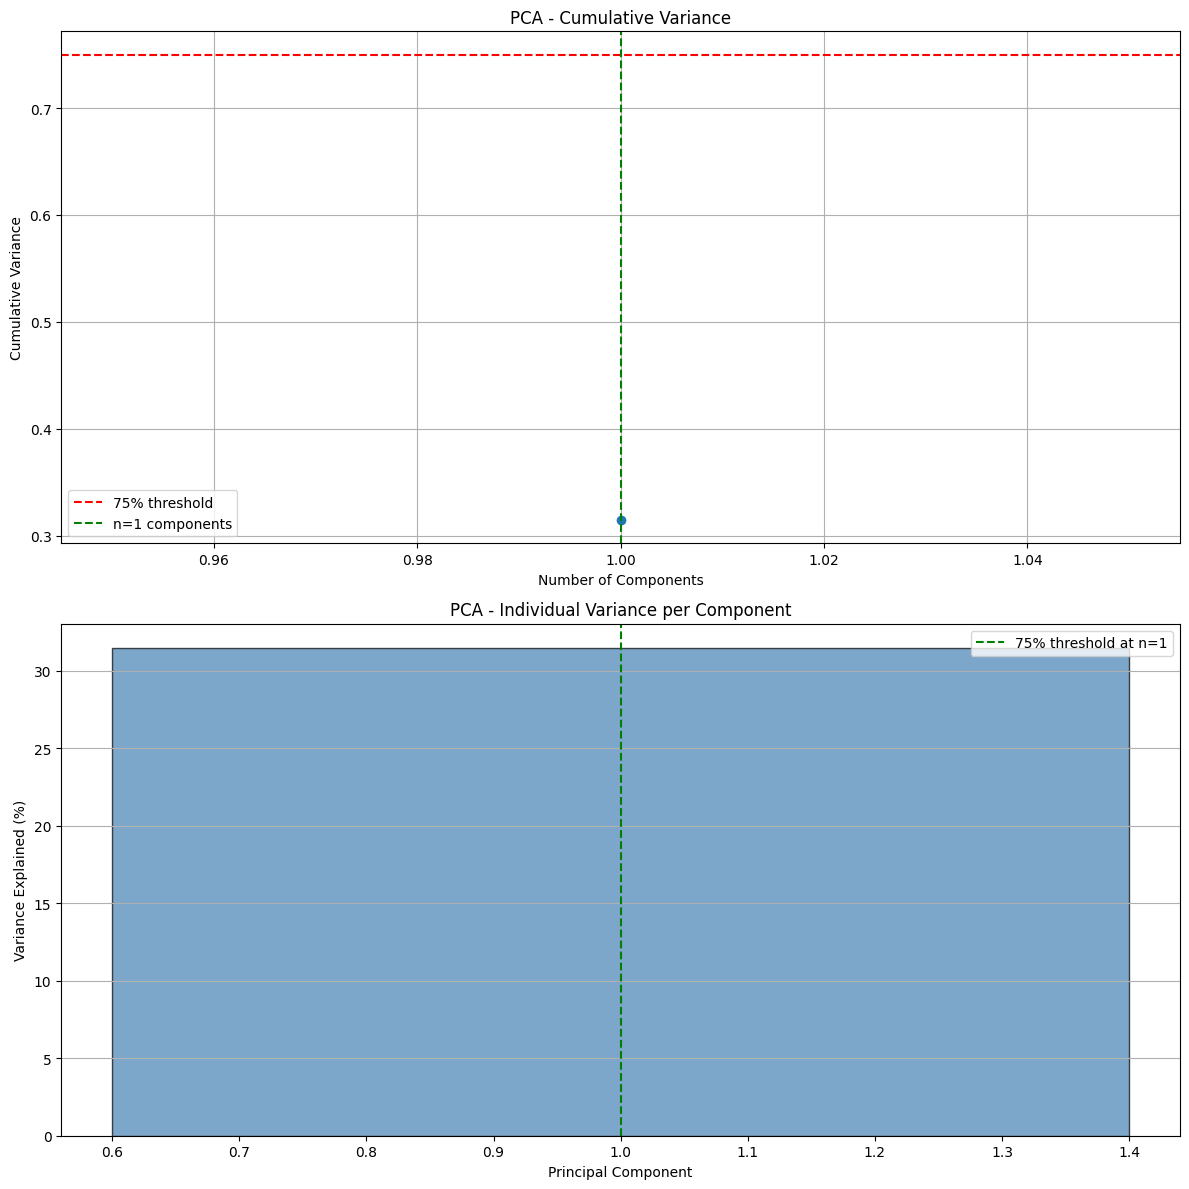

✅ Components needed for 75% variance: 1
✅ Variance explained by 1 components: 0.3146


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [11]:
X_train_pca_df = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_test_pca_df = pd.DataFrame(X_test_pca, columns=[f'PC{i+1}' for i in range(X_test_pca.shape[1])])

X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

X_train_pca = pd.concat([X_train_pca_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_df,  X_test_raw_month,  X_test_fe],       axis=1)

# LazyPred

In [ ]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

In [ ]:
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train_pca, X_test_pca, y_train, y_test)

print(models)

In [12]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# OpTuna

In [13]:
# ── prepare a version of X_train that already has month columns ──
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12',
              'Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

X_train_no_month = X_train_raw.copy() 
X_train_month = pd.concat([
    X_train_raw_month.reset_index(drop=True),
    X_train_raw_fe.reset_index(drop=True)
], axis=1)

# helper: run CV with month columns reattached after PCA inside each fold
def cv_with_month(pipeline, X_num, X_mon, y, cv=4):
    from sklearn.model_selection import KFold

    # Reset all indices upfront so iloc slicing stays aligned
    X_num = X_num.reset_index(drop=True)
    X_mon = X_mon.reset_index(drop=True)
    y     = y.reset_index(drop=True)

    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X_num):
        X_num_tr, X_num_val = X_num.iloc[train_idx], X_num.iloc[val_idx]
        X_mon_tr  = X_mon.iloc[train_idx].reset_index(drop=True)
        X_mon_val = X_mon.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        # fit the pipeline (impute+scale+pca) on numeric only
        steps_no_model = Pipeline(pipeline.steps[:-1])
        X_tr_pca  = steps_no_model.fit_transform(X_num_tr)
        X_val_pca = steps_no_model.transform(X_num_val)

        n_pcs = X_tr_pca.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_tr_final  = pd.concat([pd.DataFrame(X_tr_pca,  columns=pc_cols), X_mon_tr],  axis=1)
        X_val_final = pd.concat([pd.DataFrame(X_val_pca, columns=pc_cols), X_mon_val], axis=1)

        model = pipeline.steps[-1][1]
        model.fit(X_tr_final, y_tr)
        scores.append(model.score(X_val_final, y_val))   # R²
    return np.mean(scores)

In [14]:
def et_objective(trial):
    model = ExtraTreesRegressor(
        n_estimators     = trial.suggest_int("n_estimators", 50, 300),
        max_depth        = trial.suggest_int("max_depth", 5, 40),
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features     = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=1)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

et_study = optuna.create_study(direction="maximize")
et_study.optimize(et_objective, n_trials=50)
print("========== ET BEST ==========")
print(et_study.best_params)
print(f"Best R²: {et_study.best_value:.4f}")

[I 2026-05-15 22:39:02,009] A new study created in memory with name: no-name-18a9aa6a-84f5-454d-98e1-4199f1169989
[I 2026-05-15 22:39:03,188] Trial 0 finished with value: 0.6127011944717499 and parameters: {'n_estimators': 194, 'max_depth': 28, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6127011944717499.
[I 2026-05-15 22:39:03,850] Trial 1 finished with value: 0.507195141990226 and parameters: {'n_estimators': 127, 'max_depth': 40, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.6127011944717499.
[I 2026-05-15 22:39:04,602] Trial 2 finished with value: 0.4351184422511117 and parameters: {'n_estimators': 182, 'max_depth': 37, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6127011944717499.
[I 2026-05-15 22:39:05,197] Trial 3 finished with value: 0.255424169726148 and parameters: {'n_estimators': 154, 'max_depth': 11, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 

========== ET BEST ==========
{'n_estimators': 298, 'max_depth': 27, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best R²: 0.6132


In [15]:
def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators      = trial.suggest_int("n_estimators", 50, 300),
        max_depth         = trial.suggest_int("max_depth", 5, 40),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 5),
        max_features      = trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        n_jobs=-1, random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=1)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=50)
print("========== RF BEST ==========")
print(rf_study.best_params)
print(f"Best R²: {rf_study.best_value:.4f}")

[I 2026-05-15 22:39:50,688] A new study created in memory with name: no-name-9cf9ea90-3517-44c3-befb-8cf83689e94f
[I 2026-05-15 22:39:52,454] Trial 0 finished with value: 0.5299280228900003 and parameters: {'n_estimators': 236, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.5299280228900003.
[I 2026-05-15 22:39:54,203] Trial 1 finished with value: 0.5527208896029179 and parameters: {'n_estimators': 225, 'max_depth': 27, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.5527208896029179.
[I 2026-05-15 22:39:55,172] Trial 2 finished with value: 0.40526717682578983 and parameters: {'n_estimators': 161, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5527208896029179.
[I 2026-05-15 22:39:56,273] Trial 3 finished with value: 0.5637601696640833 and parameters: {'n_estimators': 136, 'max_depth': 21, 

========== RF BEST ==========
{'n_estimators': 219, 'max_depth': 31, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best R²: 0.6105


In [16]:
def hgb_objective(trial):
    model = HistGradientBoostingRegressor(
        max_iter          = trial.suggest_int  ("max_iter",          50, 400),
        max_depth         = trial.suggest_int  ("max_depth",          3,  15),
        learning_rate     = trial.suggest_float("learning_rate",  0.005, 0.1),
        min_samples_leaf  = trial.suggest_int  ("min_samples_leaf",   1,  50),
        l2_regularization = trial.suggest_float("l2_regularization", 0.0, 1.0),
        random_state=42
    )
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('pca',     PCA(n_components=1)),
        ('model',   model)
    ])
    return cv_with_month(pipeline, X_train_no_month, X_train_month, y_train)

hgb_study = optuna.create_study(direction="maximize")
hgb_study.optimize(hgb_objective, n_trials=50)
print("========== HGB BEST ==========")
print(hgb_study.best_params)
print(f"Best R²: {hgb_study.best_value:.4f}")

[I 2026-05-15 22:41:05,903] A new study created in memory with name: no-name-6c2fd443-6671-40a1-99f7-80e9b06602e4
[I 2026-05-15 22:41:06,351] Trial 0 finished with value: 0.21921599740474335 and parameters: {'max_iter': 136, 'max_depth': 3, 'learning_rate': 0.019066705852846484, 'min_samples_leaf': 37, 'l2_regularization': 0.5355203484279042}. Best is trial 0 with value: 0.21921599740474335.
[I 2026-05-15 22:41:07,720] Trial 1 finished with value: 0.38612169113709405 and parameters: {'max_iter': 212, 'max_depth': 7, 'learning_rate': 0.012090417678702729, 'min_samples_leaf': 25, 'l2_regularization': 0.3629795492729745}. Best is trial 1 with value: 0.38612169113709405.
[I 2026-05-15 22:41:08,239] Trial 2 finished with value: 0.46656732969603587 and parameters: {'max_iter': 63, 'max_depth': 13, 'learning_rate': 0.07708346692778104, 'min_samples_leaf': 6, 'l2_regularization': 0.03938404450654365}. Best is trial 2 with value: 0.46656732969603587.
[I 2026-05-15 22:41:10,619] Trial 3 finished

========== HGB BEST ==========
{'max_iter': 362, 'max_depth': 11, 'learning_rate': 0.07980078947589887, 'min_samples_leaf': 8, 'l2_regularization': 0.593989343678763}
Best R²: 0.5629


# Start

In [ ]:
# ========== ET BEST ==========
# {'n_estimators': 122, 'max_depth': 29, 'min_samples_leaf': 1, 'max_features': 'log2'}

# ========== RF BEST ==========
# {'n_estimators': 204, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

# ========== HGB BEST ==========
# {'max_iter': 358, 'max_depth': 13, 'learning_rate': 0.07091369752390678, 'min_samples_leaf': 1, 'l2_regularization': 0.008609248841581194}


In [17]:
hgb_model = HistGradientBoostingRegressor(
    **hgb_study.best_params,
    random_state=42
)

et_model = ExtraTreesRegressor(
    **et_study.best_params,
    n_jobs=-1,
    random_state=42
)

rf_model = RandomForestRegressor(
    **rf_study.best_params,
    n_jobs=-1, 
    random_state=42
)

# K-Fold

In [19]:
from sklearn.model_selection import KFold
from sklearn.base import clone

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Categorical/extra columns (จะ append ทีหลัง — ไม่ผ่าน PCA)
month_cols = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
              'Month_7','Month_8','Month_9','Month_10','Month_11','Month_12']
paper_features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA']

# X_extra = month + paper (จะเพิ่มทีหลัง)
X_month = X[month_cols].copy()
X_paper = X[paper_features].copy()

# X_for_pca = ทุก features รวม paper features (จะผ่าน PCA)
# แต่ตัด month ออก (เพราะ month เป็น categorical ไม่ควรเข้า PCA)
X_for_pca = X.drop(columns=month_cols)

cv_models = {
    'ExtraTrees':           et_model,
    'RandomForest':         rf_model,
    'HistGradientBoost':    hgb_model,
    'Voting (Ensemble)':    VotingRegressor([
        ('et',  et_model),
        ('rf',  rf_model),
        ('hgb', hgb_model)
    ])
}

print("=" * 70)
print("K-Fold Cross Validation Summary (k=4)")
print("=" * 70)
print(f"{'Model':<22}{'Mean R²':>14}{'Mean RMSE':>14}{'Mean MAE':>14}")
print("-" * 70)

for name, base_model in cv_models.items():
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, test_idx in kf.split(X_for_pca):
        # Split numeric (for PCA), month, and paper separately
        X_fold_train, X_fold_test = X_for_pca.iloc[train_idx], X_for_pca.iloc[test_idx]
        month_fold_train = X_month.iloc[train_idx].reset_index(drop=True)
        month_fold_test  = X_month.iloc[test_idx].reset_index(drop=True)
        paper_fold_train = X_paper.iloc[train_idx].copy()
        paper_fold_test  = X_paper.iloc[test_idx].copy()
        y_fold_train     = Y.iloc[train_idx].reset_index(drop=True)
        y_fold_test      = Y.iloc[test_idx].reset_index(drop=True)

        # Impute → Scale → PCA (numeric only — รวม paper features ใน X_fold_train)
        imputer     = SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_fold_train)
        X_test_imp  = imputer.transform(X_fold_test)

        # ⭐ NEW: Impute paper features ที่จะ reattach (แยก imputer ตามที่ noise_robustness ทำ)
        fe_imputer = SimpleImputer(strategy='median')
        paper_fold_train = pd.DataFrame(
            fe_imputer.fit_transform(paper_fold_train),
            columns=paper_features
        ).reset_index(drop=True)
        paper_fold_test = pd.DataFrame(
            fe_imputer.transform(paper_fold_test),
            columns=paper_features
        ).reset_index(drop=True)

        scaler      = StandardScaler()
        X_train_ss  = scaler.fit_transform(X_train_imp)
        X_test_ss   = scaler.transform(X_test_imp)

        pca         = PCA(n_components=1)
        X_train_pca_fold = pca.fit_transform(X_train_ss)
        X_test_pca_fold  = pca.transform(X_test_ss)

        # Reattach: PCA + month + paper(imputed)
        n_pcs   = X_train_pca_fold.shape[1]
        pc_cols = [f'PC{i+1}' for i in range(n_pcs)]

        X_train_final = pd.concat([
            pd.DataFrame(X_train_pca_fold, columns=pc_cols),
            month_fold_train,
            paper_fold_train,
        ], axis=1)
        X_test_final  = pd.concat([
            pd.DataFrame(X_test_pca_fold, columns=pc_cols),
            month_fold_test,
            paper_fold_test,
        ], axis=1)

        # Train & evaluate
        model = clone(base_model)
        model.fit(X_train_final, y_fold_train)
        preds = model.predict(X_test_final)

        r2_scores.append(r2_score(y_fold_test, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_fold_test, preds)))
        mae_scores.append(mean_absolute_error(y_fold_test, preds))

    print(f"{name:<22}{np.mean(r2_scores):>14.4f}{np.mean(rmse_scores):>14.4f}{np.mean(mae_scores):>14.4f}")

print("=" * 70)

K-Fold Cross Validation Summary (k=4)
Model                        Mean R²     Mean RMSE      Mean MAE
----------------------------------------------------------------------
ExtraTrees                    0.6605       12.5480        5.6797
RandomForest                  0.6517       12.7093        6.6017
HistGradientBoost             0.5785       13.9769        7.9302
Voting (Ensemble)             0.6554       12.6404        6.6027
